In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parent
database_path = project_root / "data" / "restaurant_risk.duckdb"
conn = duckdb.connect(str(database_path), read_only = True)
print(f"Project root: {project_root}")
print(f"Database: {database_path}")

Project root: C:\Users\User\projects\restaurant-inspection-prioritization
Database: C:\Users\User\projects\restaurant-inspection-prioritization\data\restaurant_risk.duckdb


## 1. Load the Modeling Dataset

In [2]:
modeling_query = """
SELECT
    f.*,

    l.cutoff_inspection_type,
    l.cutoff_is_cycle_initial,
    l.cutoff_is_cycle_reinspection,

    l.target_inspection_id,
    l.target_inspection_date,
    l.target_inspection_type,
    l.days_to_target,

    l.target_total_violations,
    l.target_critical_violation_count,

    l.target_any_critical,
    l.target_two_or_more_critical,
    l.target_three_or_more_critical,
    l.target_four_or_more_critical,

    l.target_high_severity,
    l.target_label

FROM processed.features AS f
INNER JOIN processed.labels AS l
    ON f.cutoff_inspection_id = l.cutoff_inspection_id
"""

df = conn.execute(modeling_query).df()

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

Rows: 36,037
Columns: 55


In [3]:
df.shape

(36037, 55)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36037 entries, 0 to 36036
Data columns (total 55 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   camis                                         36037 non-null  str           
 1   cutoff_inspection_id                          36037 non-null  str           
 2   cutoff_date                                   36037 non-null  datetime64[us]
 3   feature_source_max_date                       36037 non-null  datetime64[us]
 4   violation_feature_source_max_date             35899 non-null  datetime64[us]
 5   prior_cycle_inspection_count                  36037 non-null  int64         
 6   prior_cycle_initial_count                     36037 non-null  int64         
 7   prior_cycle_reinspection_count                36037 non-null  int64         
 8   prior_critical_inspection_count               36037 non-null  int64         


In [5]:
df.head()

,camis,cutoff_inspection_id,cutoff_date,feature_source_max_date,violation_feature_source_max_date,prior_cycle_inspection_count,prior_cycle_initial_count,prior_cycle_reinspection_count,prior_critical_inspection_count,prior_cycle_initial_critical_count,...,target_inspection_type,days_to_target,target_total_violations,target_critical_violation_count,target_any_critical,target_two_or_more_critical,target_three_or_more_critical,target_four_or_more_critical,target_high_severity,target_label
0,50065575,07c9ecf0e207528a6cbf0354689b576e,2024-05-29,2024-05-29,2024-05-29,2,2,0,1,1,...,Cycle Inspection / Initial Inspection,660,3,1,1,0,0,0,0,below_high_severity_threshold
1,50120864,12b3c84f508d98c354bdcce7c90a3d9b,2024-05-08,2024-05-08,2024-05-08,2,1,1,2,1,...,Cycle Inspection / Initial Inspection,526,3,1,1,0,0,0,0,below_high_severity_threshold
2,41431607,12cfa340a6820ee24227dd6a36ec2bd8,2024-05-15,2024-05-15,2024-05-15,2,1,1,2,1,...,Cycle Inspection / Initial Inspection,512,2,0,0,0,0,0,0,below_high_severity_threshold
3,50043074,16193a9c5de06c9c0481f92cadfe2b15,2024-12-06,2024-12-06,2024-12-06,1,1,0,0,0,...,Cycle Inspection / Initial Inspection,609,2,1,1,0,0,0,0,below_high_severity_threshold
4,41047349,1ae60b760d3f8a6c7883e2d4d12c524f,2025-01-14,2025-01-14,2025-01-14,2,2,0,2,2,...,Cycle Inspection / Initial Inspection,468,3,0,0,0,0,0,0,below_high_severity_threshold


## 2. Analytical Dataset Validity

In [6]:
required_columns = [
    "camis",
    "cutoff_inspection_id",
    "cutoff_date",
    "target_inspection_id",
    "target_inspection_date",
    "target_inspection_type",
    "days_to_target",
    "target_high_severity",
    "history_depth_bucket",
]

missing_columns = [column for column in required_columns if column not in df.columns]
print("Missing required columns:", missing_columns)

Missing required columns: []


In [7]:
df["cutoff_date"] = pd.to_datetime(df["cutoff_date"])
df["target_inspection_date"] = pd.to_datetime(df["target_inspection_date"])

print(f"Rows: {len(df)}" )
print(f"Unique cutoff inspection IDs: {df.cutoff_inspection_id.nunique()}")
print(f"Duplicate cutoff inspection IDs: {df.cutoff_inspection_id.duplicated().sum()}")
print(f"Null high severity targets: {df.target_high_severity.isna().sum()}")
print(f"Targets not strictly after cutoff: {(df.target_inspection_date <= df.cutoff_date).sum()}")
print(f"Negative target horizons: {(df.days_to_target <= 0).sum()}")
print(f"Non binary high severity targets: {(~df.target_high_severity.isin([0, 1])).sum()}")

Rows: 36037
Unique cutoff inspection IDs: 36037
Duplicate cutoff inspection IDs: 0
Null high severity targets: 0
Targets not strictly after cutoff: 0
Negative target horizons: 0
Non binary high severity targets: 0


## 3. Dataset Card

In [8]:
dataset_card = pd.DataFrame(
    {
        "metric": [
            "Prediction examples",
            "Unique restaurants",
            "Unique cutoff inspections",
            "Unique target inspections",
            "Earliest cutoff date",
            "Latest cutoff date",
            "Earliest target date",
            "Latest target date",
            "High-severity positives",
            "High-severity target prevalence",
            "Median days to target",
        ],
        "value": [
            len(df),
            df["camis"].nunique(),
            df["cutoff_inspection_id"].nunique(),
            df["target_inspection_id"].nunique(),
            df["cutoff_date"].min().date(),
            df["cutoff_date"].max().date(),
            df["target_inspection_date"].min().date(),
            df["target_inspection_date"].max().date(),
            int(df["target_high_severity"].sum()),
            f"{df['target_high_severity'].mean():.2%}",
            float(df["days_to_target"].median()),
        ],
    }
)

dataset_card

,metric,value
0,Prediction examples,36037
1,Unique restaurants,17561
2,Unique cutoff inspections,36037
3,Unique target inspections,26618
4,Earliest cutoff date,2010-02-26
5,Latest cutoff date,2026-05-29
6,Earliest target date,2010-04-29
7,Latest target date,2026-08-22
8,High-severity positives,10680
9,High-severity target prevalence,29.64%


## 4. Target Severity Audit

In [9]:
target_columns = [
    "target_any_critical",
    "target_two_or_more_critical",
    "target_three_or_more_critical",
    "target_four_or_more_critical",
    "target_high_severity",
]

target_severity_summary = (
    df[target_columns]
    .agg(["sum", "mean"])
    .T
    .rename(
        columns={
            "sum": "positive_examples",
            "mean": "positive_rate",
        }
    )
)

target_severity_summary

,positive_examples,positive_rate
target_any_critical,32020.0,0.888531
target_two_or_more_critical,18396.0,0.510475
target_three_or_more_critical,10680.0,0.296362
target_four_or_more_critical,5568.0,0.154508
target_high_severity,10680.0,0.296362


In [10]:
target_type_summary = (df.groupby("target_inspection_type", dropna=False,)["target_high_severity"]
    .agg(examples="size", positive_targets="sum", target_rate="mean",)
    .reset_index()
    .sort_values("examples", ascending=False))

target_type_summary

,target_inspection_type,examples,positive_targets,target_rate
0,Cycle Inspection / Initial Inspection,36037,10680,0.296362


## 5. Prediction Horizon and Temporal Coverage

In [11]:
horizon_summary = (df.days_to_target.describe(percentiles = [0.05, 0.25, 0.50, 0.75, 0.90, 0.95]).to_frame(name = "days_to_target"))
horizon_summary                

,days_to_target
count,36037.000000
mean,472.343009
std,179.734498
min,3.000000
5%,151.000000
25%,371.000000
50%,481.000000
75%,567.000000
90%,690.000000
95%,783.000000


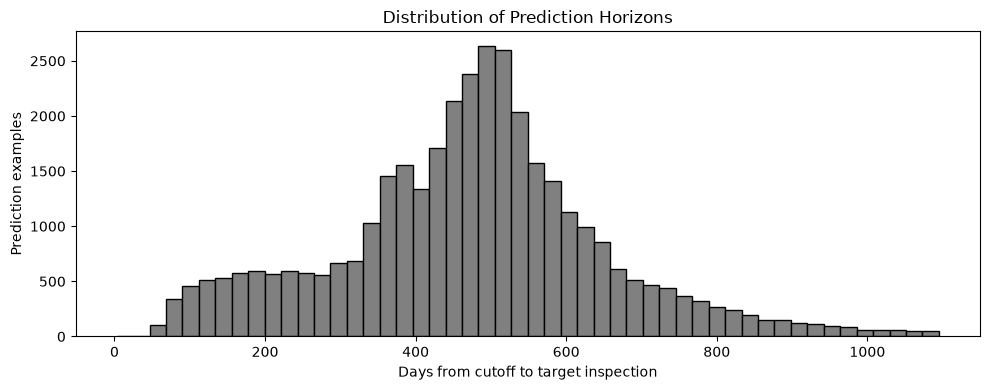

In [12]:
plt.figure(figsize = (10,4))
plt.hist(df.days_to_target.dropna(), bins=50, color="grey", edgecolor="black")
plt.xlabel("Days from cutoff to target inspection")
plt.ylabel("Prediction examples")
plt.title("Distribution of Prediction Horizons")
plt.tight_layout()
plt.show()

In [13]:
df.horizon_bucket = pd.cut(df.days_to_target, bins=[0, 90, 180, 365, 730, float("inf")], labels=[ "0–90 days", "91–180 days", "181–365 days", "366–730 days", "731+ days",])
horizon_target_summary = (df.groupby("horizon_bucket",observed=False,)["target_high_severity"]
    .agg(examples="size", positive_targets="sum", target_rate="mean",)
    .reset_index())
horizon_target_summary

C:\Users\User\AppData\Local\Temp\ipykernel_40072\2707867111.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.horizon_bucket = pd.cut(df.days_to_target, bins=[0, 90, 180, 365, 730, float("inf")], labels=[ "0–90 days", "91–180 days", "181–365 days", "366–730 days", "731+ days",])


KeyError: 'horizon_bucket'

In [ ]:
df["cutoff_quarter"] = df["cutoff_date"].dt.to_period("Q")
quarterly_summary = (df.groupby("cutoff_quarter")["target_high_severity"].agg(examples="size", positive_targets="sum", target_rate="mean").reset_index())
quarterly_summary

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(quarterly_summary.cutoff_quarter.astype(str), quarterly_summary.target_rate, marker = "o")
plt.xticks(rotation=60)
plt.xlabel("Cutoff quarter")
plt.ylabel("High-severity target rate")
plt.title("High-Severity Target Prevalence Over Time")
plt.tight_layout()
plt.show()

## 6. Inspection Process Analysis

In [ ]:
cutoff_type_summary = (df.groupby("cutoff_inspection_type", dropna = False)["target_high_severity"]
                       .agg(examples = "size", positive_targets = "sum", target_rate = "mean")
                       .reset_index())
cutoff_type_summary["population_share"] = (cutoff_type_summary.examples / cutoff_type_summary.examples.sum())
cutoff_type_summary

## 7. History-Depth Analysis

In [ ]:
history_depth_summary = (df.groupby("history_depth_bucket", observed=False)
    .agg(examples=("target_high_severity", "size"), unique_restaurants=("camis", "nunique"), positive_targets=("target_high_severity", "sum"), 
        target_rate=("target_high_severity", "mean"),median_days_to_target=("days_to_target", "median"),median_prior_critical_rate=("prior_critical_inspection_rate","median",
        )).reset_index())

history_depth_summary

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(history_depth_summary["history_depth_bucket"], history_depth_summary["target_rate"],)
plt.xlabel("Prior Cycle-Initial Inspection History")
plt.ylabel("High-Severity Target Rate")
plt.title("High-Severity Outcome Rate by History Depth")
plt.tight_layout()
plt.show()

## 8. Feature Quality and Missingness

In [ ]:
numeric_features = [
    "prior_cycle_inspection_count",
    "prior_cycle_initial_count",
    "prior_cycle_reinspection_count",
    "prior_critical_inspection_count",
    "prior_critical_inspection_rate",
    "prior_critical_violation_count",
    "days_since_last_cycle_inspection",
    "days_since_last_critical_inspection",
    "max_historical_score",
    "average_historical_score",
    "average_score_last_365d",
    "cycle_inspections_last_365d",
    "critical_cycle_inspections_last_365d",
    "prior_total_violations",
    "prior_critical_violation_rows",
    "violations_last_365d",
    "critical_violations_last_365d",
]

categorical_features = [
    "borough",
    "cuisine_description",
    "zipcode",
    "nta",
    "community_board",
    "history_depth_bucket",
]

missing_feature_columns = [
    column
    for column in numeric_features + categorical_features
    if column not in df.columns
]

print("Feature columns missing from df:", missing_feature_columns)

In [ ]:
missingness_summary = (df[numeric_features + categorical_features].isna().mean().mul(100).sort_values(ascending=False).rename("missing_pct").to_frame())
missingness_summary

In [ ]:
numeric_summary = (df[numeric_features].describe(percentiles=[0.01,0.05,0.25,0.50,0.75,0.95,0.99]).T)
numeric_summary

In [ ]:
for column in categorical_features:
    print(f"{column}")
    print("Unique values:", df[column].nunique(dropna=False))
    display(df[column].value_counts(dropna=False).head(15))

## 9. Baseline Signal Before Machine Learning

In [ ]:
df["has_prior_critical_outcome"] = np.where(df["prior_critical_inspection_count"] > 0,"At least one prior critical outcome","No prior critical outcome")
prior_critical_summary = (df.groupby("has_prior_critical_outcome", dropna=False)["target_high_severity"]
    .agg(examples="size", positive_targets="sum", target_rate="mean").reset_index())
prior_critical_summary

In [ ]:
df["prior_critical_rate_bucket"] = pd.cut(df["prior_critical_inspection_rate"],bins=[-0.01, 0, 0.25, 0.50, 0.75, 1.0],labels=["0%","0–25%","25–50%","50–75%","75–100%"])
historical_rate_summary = (df.groupby("prior_critical_rate_bucket",observed=False)["target_high_severity"]
    .agg(examples="size",positive_targets="sum",target_rate="mean").reset_index())
historical_rate_summary

In [ ]:
def summarize_top_k_policy(
    data: pd.DataFrame,
    score_column: str,
    policy_name: str,
    capacity: int,
    ascending: bool = False,
) -> dict:
    selected = (
        data.sort_values(
            by=[score_column, "camis"],
            ascending=[ascending, True],
        )
        .head(capacity)
    )

    return {
        "policy": policy_name,
        "capacity": capacity,
        "selected_examples": len(selected),
        "high_severity_outcomes_found": int(
            selected["target_high_severity"].sum()
        ),
        "precision_at_k": selected[
            "target_high_severity"
        ].mean(),
    }


capacity = 100

oldest_first_result = summarize_top_k_policy(
    data=df,
    score_column="days_since_last_cycle_inspection",
    policy_name="oldest_inspection_first",
    capacity=capacity,
)

historical_risk_result = summarize_top_k_policy(
    data=df,
    score_column="prior_critical_inspection_rate",
    policy_name="unsmoothed_historical_risk",
    capacity=capacity,
)

random_expected_precision = df["target_high_severity"].mean()
random_expected_yield = capacity * random_expected_precision

random_result = {
    "policy": "random_expected",
    "capacity": capacity,
    "selected_examples": capacity,
    "high_severity_outcomes_found": random_expected_yield,
    "precision_at_k": random_expected_precision,
}

exploratory_policy_results = pd.DataFrame(
    [
        random_result,
        oldest_first_result,
        historical_risk_result,
    ]
)

exploratory_policy_results

In [14]:
new_high_severity_feature_summary = (
    df[
        [
            "prior_high_severity_inspection_count",
            "prior_high_severity_inspection_rate",
            "high_severity_cycle_inspections_last_365d",
            "days_since_last_high_severity_inspection",
            "target_high_severity",
        ]
    ]
    .describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95],
    )
    .T
)

new_high_severity_feature_summary

,count,mean,std,min,5%,25%,50%,75%,95%,max
prior_high_severity_inspection_count,36037.0,0.571551,0.809958,0.0,0.0,0.0,0.0,1.0,2.0,8.0
prior_high_severity_inspection_rate,36037.0,0.297191,0.388892,0.0,0.0,0.0,0.0,0.5,1.0,1.0
high_severity_cycle_inspections_last_365d,36037.0,0.487638,0.680952,0.0,0.0,0.0,0.0,1.0,2.0,6.0
days_since_last_high_severity_inspection,15338.0,83.116443,147.287131,0.0,0.0,0.0,0.0,115.0,420.0,899.0
target_high_severity,36037.0,0.296362,0.456659,0.0,0.0,0.0,0.0,1.0,1.0,1.0


In [15]:
df["prior_high_severity_rate_bucket"] = pd.cut(
    df["prior_high_severity_inspection_rate"],
    bins=[-0.01, 0, 0.25, 0.50, 0.75, 1.0],
    labels=[
        "0%",
        "0–25%",
        "25–50%",
        "50–75%",
        "75–100%",
    ],
)

(
    df.groupby(
        "prior_high_severity_rate_bucket",
        observed=False,
    )["target_high_severity"]
    .agg(
        examples="size",
        positive_targets="sum",
        target_rate="mean",
    )
    .reset_index()
)

,prior_high_severity_rate_bucket,examples,positive_targets,target_rate
0,0%,20699,4499,0.217353
1,0–25%,539,122,0.226345
2,25–50%,6950,2371,0.341151
3,50–75%,1294,591,0.456723
4,75–100%,6555,3097,0.472464


## 10. Historical High-Severity Signal

In [16]:
df["has_prior_high_severity_outcome"] = np.where(
    df["prior_high_severity_inspection_count"] > 0,
    "At least one prior high-severity outcome",
    "No prior high-severity outcome",
)

prior_high_severity_summary = (
    df.groupby(
        "has_prior_high_severity_outcome",
        dropna=False,
    )["target_high_severity"]
    .agg(
        examples="size",
        positive_targets="sum",
        target_rate="mean",
    )
    .reset_index()
)

prior_high_severity_summary

,has_prior_high_severity_outcome,examples,positive_targets,target_rate
0,At least one prior high-severity outcome,15338,6181,0.402986
1,No prior high-severity outcome,20699,4499,0.217353


In [17]:
df["high_severity_recency_bucket"] = pd.cut(
    df["days_since_last_high_severity_inspection"],
    bins=[-1, 30, 90, 180, 365, float("inf")],
    labels=[
        "0–30 days",
        "31–90 days",
        "91–180 days",
        "181–365 days",
        "366+ days",
    ],
)

recency_summary = (
    df.groupby(
        "high_severity_recency_bucket",
        observed=False,
    )["target_high_severity"]
    .agg(
        examples="size",
        positive_targets="sum",
        target_rate="mean",
    )
    .reset_index()
)

recency_summary

,high_severity_recency_bucket,examples,positive_targets,target_rate
0,0–30 days,9956,4340,0.435918
1,31–90 days,1159,448,0.386540
2,91–180 days,1240,447,0.360484
3,181–365 days,2000,683,0.341500
4,366+ days,983,263,0.267548


In [18]:
df["high_severity_recency_available"] = np.where(
    df["days_since_last_high_severity_inspection"].isna(),
    "No observed prior high-severity event",
    "Observed prior high-severity event",
)

recency_missingness_summary = (
    df.groupby(
        "high_severity_recency_available",
        dropna=False,
    )["target_high_severity"]
    .agg(
        examples="size",
        positive_targets="sum",
        target_rate="mean",
    )
    .reset_index()
)

recency_missingness_summary

,high_severity_recency_available,examples,positive_targets,target_rate
0,No observed prior high-severity event,20699,4499,0.217353
1,Observed prior high-severity event,15338,6181,0.402986


## 11. Exploratory Fixed-Capacity Baseline Policies


In [21]:
def summarize_top_k_policy(
    data: pd.DataFrame,
    score_column: str,
    policy_name: str,
    capacity: int,
    ascending: bool = False,
) -> dict:
    selected = (
        data.sort_values(
            by=[score_column, "camis"],
            ascending=[ascending, True],
        )
        .head(capacity)
    )

    precision_at_k = selected["target_high_severity"].mean()

    return {
        "policy": policy_name,
        "capacity": capacity,
        "selected_examples": len(selected),
        "high_severity_outcomes_found": int(
            selected["target_high_severity"].sum()
        ),
        "precision_at_k": precision_at_k,
        "lift_vs_random": (
            precision_at_k / data["target_high_severity"].mean()
        ),
    }

In [22]:
capacities = [50, 100, 250, 500]

policy_rows = []

for capacity in capacities:
    random_expected_precision = df["target_high_severity"].mean()

    policy_rows.append(
        {
            "policy": "random_expected",
            "capacity": capacity,
            "selected_examples": capacity,
            "high_severity_outcomes_found": (
                capacity * random_expected_precision
            ),
            "precision_at_k": random_expected_precision,
            "lift_vs_random": 1.0,
        }
    )

    policy_rows.append(
        summarize_top_k_policy(
            data=df,
            score_column="days_since_last_cycle_inspection",
            policy_name="oldest_inspection_first",
            capacity=capacity,
            ascending=False,
        )
    )

    policy_rows.append(
        summarize_top_k_policy(
            data=df,
            score_column="prior_high_severity_inspection_rate",
            policy_name="unsmoothed_high_severity_history",
            capacity=capacity,
            ascending=False,
        )
    )

exploratory_policy_results = pd.DataFrame(policy_rows)

exploratory_policy_results

,policy,capacity,selected_examples,high_severity_outcomes_found,precision_at_k,lift_vs_random
0,random_expected,50,50,14.818104,0.296362,1.000000
1,oldest_inspection_first,50,50,9.000000,0.180000,0.607365
2,unsmoothed_high_severity_history,50,50,16.000000,0.320000,1.079760
3,random_expected,100,100,29.636207,0.296362,1.000000
4,oldest_inspection_first,100,100,22.000000,0.220000,0.742335
5,unsmoothed_high_severity_history,100,100,39.000000,0.390000,1.315958
6,random_expected,250,250,74.090518,0.296362,1.000000
7,oldest_inspection_first,250,250,56.000000,0.224000,0.755832
8,unsmoothed_high_severity_history,250,250,92.000000,0.368000,1.241724
9,random_expected,500,500,148.181036,0.296362,1.000000


## 12. Primary Modeling Cohort and Temporal Split

In [23]:
modeling_cohort = df[
    (df["cutoff_date"] >= "2022-01-01")
    & (df["cutoff_date"] < "2026-01-01")
].copy()

train_df = modeling_cohort[
    modeling_cohort["cutoff_date"] < "2024-01-01"
].copy()

validation_df = modeling_cohort[
    (modeling_cohort["cutoff_date"] >= "2024-01-01")
    & (modeling_cohort["cutoff_date"] < "2025-01-01")
].copy()

test_df = modeling_cohort[
    (modeling_cohort["cutoff_date"] >= "2025-01-01")
    & (modeling_cohort["cutoff_date"] < "2026-01-01")
].copy()

In [24]:
split_summary_rows = []

for split_name, split_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    split_summary_rows.append(
        {
            "split": split_name,
            "examples": len(split_df),
            "unique_restaurants": split_df["camis"].nunique(),
            "positive_targets": int(
                split_df["target_high_severity"].sum()
            ),
            "target_prevalence": split_df[
                "target_high_severity"
            ].mean(),
            "start_cutoff": split_df["cutoff_date"].min().date(),
            "end_cutoff": split_df["cutoff_date"].max().date(),
        }
    )

split_summary = pd.DataFrame(split_summary_rows)

split_summary

,split,examples,unique_restaurants,positive_targets,target_prevalence,start_cutoff,end_cutoff
0,train,12865,10070,3559,0.276642,2022-01-03,2023-12-29
1,validation,16057,12991,4531,0.282182,2024-01-02,2024-12-31
2,test,6396,4607,2379,0.371951,2025-01-02,2025-12-31


In [25]:
assert train_df["cutoff_date"].max() < validation_df["cutoff_date"].min()
assert validation_df["cutoff_date"].max() < test_df["cutoff_date"].min()

assert len(train_df) > 0
assert len(validation_df) > 0
assert len(test_df) > 0

assert train_df["target_high_severity"].sum() > 0
assert validation_df["target_high_severity"].sum() > 0
assert test_df["target_high_severity"].sum() > 0

print("Chronological split integrity checks passed.")

Chronological split integrity checks passed.


## 13. EDA Conclusions and Modeling Decisions

### Dataset integrity

- The final analytical dataset contains 36,037 retrospective decision
  snapshots and 17,561 restaurants.
- Every cutoff inspection ID is unique.
- The target is binary, non-null, and strictly later than its cutoff.
- Decision: proceed to temporal model development.

### Target definition

- The original any-critical target was too prevalent for useful prioritization.
- The final target is three or more critical violations at the next
  `Cycle Inspection / Initial Inspection`.
- The high-severity target prevalence is 29.64%.
- Decision: use `target_high_severity` as the canonical supervised-learning
  target.

### Temporal population

- Historical cutoff coverage is sparse and irregular before 2022.
- The 2026 period is incomplete and has insufficient volume for final testing.
- Decision: use the 2022–2025 cohort, with 2022–2023 for training, 2024 for
  calibration/validation, and 2025 as the untouched final test period.
  
### Temporal prevalence shift

- High-severity target prevalence was 27.66% in the 2022–2023 training
  period, 28.22% in the 2024 validation period, and 37.20% in the 2025
  final test period.
- Decision: treat 2025 as a genuine future distribution-shift test. Evaluate
  both ranking performance and probability calibration; do not assume
  validation-period calibration will remain perfect in the later period.

### Historical high-severity signal

- Restaurants with at least one observed prior high-severity inspection have
  a 40.30% future high-severity target rate, compared with 21.74% for those
  with none.
- Future high-severity rates decrease as the prior high-severity event becomes
  less recent, from 43.59% for 0–30 days to 26.75% for 366+ days.
- Decision: retain high-severity count, historical rate, recent count, and
  high-severity recency features for the first model.

### Feature exclusions and preprocessing

- `days_since_last_cycle_inspection` is structurally zero under the
  event-triggered cutoff definition.
- `prior_critical_inspection_rate` is saturated because any critical violation
  is common.
- Decision: retain both only as audit fields; exclude them from the model.
- `days_since_last_high_severity_inspection` is missing when no prior
  high-severity event exists.
- Decision: use train-only median imputation plus a missingness indicator.

### Baseline policies

- Exploratory full-dataset analysis found that an unsmoothed historical
  high-severity-rate ranking selected 39 high-severity outcomes among its
  top 100 examples, compared with a random expected yield of 29.64.
- This result is exploratory only because it uses all available periods and
  does not use a training-only smoothing prior.
- `days_since_last_cycle_inspection` is structurally zero under the
  event-triggered cutoff design. Therefore, an oldest-inspection-first policy
  cannot be meaningfully evaluated in this retrospective setup and is removed
  from final policy comparison.
- Decision: evaluate random expected selection, a training-smoothed historical
  high-severity-risk policy, logistic regression, and—only if justified—a
  constrained gradient-boosted model at fixed inspection capacities.

### Final model-selection criterion

- Select the simplest model/policy that improves fixed-capacity high-severity
  outcome yield on the validation period and remains calibrated.
- Final evaluation will report precision@N, yield@N, lift@N, incremental yield
  versus the historical-risk policy, Brier score, and calibration on the
  untouched 2025 test period.

In [26]:
conn.close()
print("DuckDB connection closed.")

DuckDB connection closed.
